In [121]:
import reframed
from pathlib import Path
import pandas as pd
import json
import numpy as np
from reframed.solvers.solution import Status
import pickle

import sys
sys.path.append('../../code/7_GEM_reconstruction')

from matplotlib import pyplot as plt
import scipy.stats as st

from ng_utils import set_auxotrophy_dict


import sys
sys.path.append('../../code/6_CRM')
from CRM import CRM
from CRM_utils import make_D, numerical_error, has_converged, make_C



# Evaluate model performance

In [122]:
repo_folder = Path("../..")
gem_data_folder = repo_folder / "data" / "7_GEM_reconstruction"
polished_folder = gem_data_folder / 'models/polished'
growth_data_folder = repo_folder / 'data' / '1_growth_phenotyping'
binary_growth_data_path = growth_data_folder / 'growth_no_growth.csv'
carbon_source_id_path = growth_data_folder / 'selected_carbon_sources.csv'#'carbon_source_ids_curated.csv'
data_folder = repo_folder / 'data/8_FBA'

In [123]:
auxotrophy_dict = {
'Ml': {'amino acids': ['cys__L'], 'vitamins':['thm', 'btn']},#'pro__L',
'Oa': {'vitamins': ['thm']}
}
auxotrophy_constraints = set_auxotrophy_dict(auxotrophy_dict)

In [124]:
species = model_abbrvs = ['At', 'Ct', 'Ml', 'Oa']
model_dict = {}
for abbrv in model_abbrvs:
    model_path = polished_folder / f'{abbrv}.xml'
    model = reframed.load_cbmodel(str(model_path))
    model_dict[abbrv] = model

# Estimate energy content and cs uptake

In [125]:
model_data = {}
shadow_prices = {}
for name, model in model_dict.items():
    
    model.reactions['R_EX_glc__D_e'].lb = 0
    
    model.reactions['R_EX_ac_e'].lb = 0
    exchanges = [r_id for r_id in model.reactions if r_id.startswith('R_EX_')]
    default_exchanges = [r_id for r_id in exchanges if model.reactions[r_id].lb < 0]
    check_exchanges = [r_id for r_id in exchanges if r_id not in default_exchanges]



    growth_exchanges = []
    energy_dict = {}
    sol_dict = {}
    print(name, reframed.FBA(model, objective='Growth', minimize=False))
    sp_dict = {}
    for r_id in check_exchanges:
        sol = reframed.FBA(model, constraints={r_id:(-5, 0)}, objective='Growth', minimize=False, shadow_prices=True)
        if sol.status == Status.OPTIMAL and sol.fobj > 0.02:
            sol9 = reframed.FBA(model, constraints={r_id:(-4, 0)}, objective='Growth', minimize=False)
            growth_exchanges.append(r_id)
            energy_dict[r_id] = sol.fobj - sol9.fobj
            sp_dict[r_id] = sol.shadow_prices
            sol_dict[r_id] = (sol.fobj, sol9.fobj)
            # sol_min = reframed.FBA(model, constraints={'Growth':(1e-4,10), r_id:(-10, 0)}, objective=r_id, minimize=False)
            # min_dict[r_id] = sol_min.fobj
            # print(r_id, sol.fobj, sol9.fobj, energy_dict[r_id], sol.fobj/10/energy_dict[r_id])
    model_data[name] = {
        'growth_exchanges': growth_exchanges,
        'energy_dict': energy_dict,
        # 'min_dict': min_dict,
        'sol_dict': sol_dict
    }
    shadow_prices[name] = sp_dict
        

At Objective: None
Status: Infeasible or Unbounded

Ct Objective: None
Status: Infeasible or Unbounded

Ml Objective: None
Status: Infeasible or Unbounded

Oa Objective: None
Status: Infeasible or Unbounded



In [126]:
intercept_dict = {}
for name, data in model_data.items():
    sol_dict = data['sol_dict']
    intercept_dict[name] = {}
    for r_id, (g2, g1) in sol_dict.items():
        slope, intercept = np.polyfit([4,5], [g1, g2], 1)
        intercept_dict[name][r_id] = intercept

In [127]:
maintenance_dict = {}
for name, data in model_data.items():
    intercepts = intercept_dict[name].values()
    maintenance_dict[name] = np.median(list(intercepts))


In [128]:
maintenance_dict

{'At': np.float64(-0.0125837587130891),
 'Ct': np.float64(-0.012816370603787963),
 'Ml': np.float64(-0.0004726177286012512),
 'Oa': np.float64(-0.01248981922545357)}

In [129]:
m = 0.0125 

# Define potential released metaboilites

In [241]:
all_growth_exchanges = set()
for name in species:
    all_growth_exchanges.update(model_data[name]['growth_exchanges'])

all_growth_exchanges.update(['R_EX_btn_e', 'R_EX_thm_e'])


## Intracellular

In [242]:
# Intracellular
for name, model in model_dict.items():
    print(name)
    temp_list = []
    for r_id in all_growth_exchanges:
        if r_id in model.reactions:
            m_id = model.reactions[r_id].get_substrates()[0]
            m_id = f'{m_id[:-2]}_c'
            # Add a temporary demand reaction for the exchange
            dm_id = f'R_DM_{m_id}'
            model.add_reaction_from_str(f'{dm_id}: {m_id} <->  [0, 1000]')
            sol = reframed.FBA(model, constraints={'R_EX_glc__D_e':(-10, 0), 'R_EX_ac_e':(-10, 0), 'R_EX_glu__L_e':(-10, 0), dm_id:(0,1000)}, objective=dm_id, minimize=False)
            model.remove_reactions([dm_id])
            if sol.status == Status.OPTIMAL and sol.fobj > 0.05:
                print(r_id, sol.fobj, sol.values[dm_id])
                temp_list.append(r_id)
        # else:
        #     if sol.status == Status.OPTIMAL:
        #         print(r_id, sol.status, sol.values[dm_id], m_id)
    model_data[name]['in_production_exchanges'] = temp_list

At
R_EX_orot_e 26.000000000000007 26.000000000000007
R_EX_sucr_e 9.25603448275862 9.25603448275862
R_EX_etoh_e 37.08658536585366 37.08658536585366
R_EX_gly_e 60.0 60.0
R_EX_tyr__L_e 11.442628774422733 11.442628774422733
R_EX_4abut_e 25.437113402061854 25.437113402061854
R_EX_glyc3p_e 31.121739130434783 31.121739130434783
R_EX_for_e 80.0000000000002 80.0000000000002
R_EX_arg__L_e 15.000000000000039 15.000000000000039
R_EX_thm_e 5.8832876712328765 5.8832876712328765
R_EX_ins_e 11.341901408450704 11.341901408450704
R_EX_spmd_e 12.305952380952386 12.305952380952386
R_EX_hxan_e 15.0 15.0
R_EX_quin_e 15.828501228501212 15.828501228501212
R_EX_acon_C_e 21.66666666666667 21.66666666666667
R_EX_fum_e 32.5 32.5
R_EX_glc__D_e 18.512068965517244 18.512068965517244
R_EX_cgly_e 16.755371900826447 16.755371900826447
R_EX_ser__L_e 40.0 40.0
R_EX_anhgm_e 5.509239130434783 5.509239130434783
R_EX_ac_e 62.5 62.5
R_EX_met_L_ala__L_e 10.958914728682135 10.958914728682135
R_EX_ppa_e 35.714285714285715 35.714

In [243]:
all_in_production_exchanges = set()
for name in species:
    all_in_production_exchanges.update(model_data[name]['in_production_exchanges'])

## Extracellular

In [244]:
# Intracellular
for name, model in model_dict.items():
    print(name)
    temp_list = []
    for r_id in all_growth_exchanges:
        if r_id not in model.reactions:
            continue
        # Add a temporary demand reaction for the exchange
        sol = reframed.FBA(model, constraints={'R_EX_glc__D_e':(-10, 0), 'R_EX_ac_e':(-10, 0), 'R_EX_glu__L_e':(-10, 0), r_id:(0,1000)}, objective=r_id, minimize=False)
        if sol.status == Status.OPTIMAL and sol.fobj > 0.05:
            print(r_id, sol.fobj, sol.values[r_id])
            temp_list.append(r_id)
        # else:
        #     if sol.status == Status.OPTIMAL:
        #         print(r_id, sol.status, sol.values[dm_id], m_id)
    model_data[name]['ex_production_exchanges'] = temp_list

At
R_EX_orot_e 26.0 26.0
R_EX_etoh_e 37.08658536585368 37.08658536585368
R_EX_gly_e 60.0 60.0
R_EX_tyr__L_e 11.442628774422692 11.442628774422692
R_EX_arg__L_e 14.99999999999997 14.99999999999997
R_EX_thm_e 5.883287671232877 5.883287671232877
R_EX_ins_e 11.282311733800356 11.282311733800356
R_EX_spmd_e 12.233136094674544 12.233136094674544
R_EX_acon_C_e 21.666666666666668 21.666666666666668
R_EX_fum_e 32.5 32.5
R_EX_glc__D_e 8.856896551724136 8.856896551724136
R_EX_ser__L_e 40.00000000000001 40.00000000000001
R_EX_anhgm_e 5.52425068119891 5.52425068119891
R_EX_ac_e 52.50000000000001 52.50000000000001
R_EX_acald_e 43.44428571428557 43.44428571428557
R_EX_fald_e 80.0 80.0
R_EX_pro__L_e 21.313402061855687 21.313402061855687
R_EX_gln__L_e 25.177551020408174 25.177551020408174
R_EX_akg_e 26.0 26.0
R_EX_leu__L_e 16.21851851851852 16.21851851851852
R_EX_pacald_e 11.031164383561643 11.031164383561643
R_EX_LalaDgluMdapDala_e 5.8900284900284925 5.8900284900284925
R_EX_ala__L_e 40.0 40.0
R_EX_pyr

In [245]:
all_ex_production_exchanges = set()
for name in species:
    all_ex_production_exchanges.update(model_data[name]['ex_production_exchanges'])

# Get all provided carbon sources

In [246]:
cs_name_to_id = pd.read_csv(carbon_source_id_path, index_col=0).to_dict()[f'BiGG ID']

assembly_data_folder = Path("../../data/2_first_community_assembly")
file_to_open = assembly_data_folder / "cfus.csv"
carbon_sources = cfus_df = pd.read_csv(file_to_open, index_col=0)['Carbon source'].unique()

In [247]:
cs_exchanges = []
for cs in carbon_sources:
    if not isinstance(cs, str):
        continue
    if '+' in cs:
        continue
    if cs == 'No CS':
        continue
    cs_short = cs.lstrip('D-').lstrip('L-')
    if cs_short not in cs_name_to_id:
        print(f'Carbon source {cs} not found in ID mapping')
        continue
    else:
        cs_exchanges.append(f'R_EX_{cs_name_to_id[cs_short]}_e')

# Define list of cs

# Get uptake rates

In [248]:
gp_folder = repo_folder / 'data/1_growth_phenotyping'
rate_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)

In [249]:
rate_df["Effective growth rate"] = rate_df["max_growth_rate"]*(rate_df["Yield"] - rate_df["y0"])/(rate_df["max_growth_rate"]*rate_df["lag"] + np.log(rate_df["Yield"]/rate_df["y0"]))

In [250]:
rate_df['Exchange reaction'] = rate_df['Carbon source'].map(cs_name_to_id).map(lambda x: f'R_EX_{x}_e')

In [251]:
growth_rate_estimate = 'max_growth_rate'

In [252]:
ex_rxn_to_mu = rate_df.set_index(['Species', 'Exchange reaction'])[growth_rate_estimate].to_dict()

In [253]:
l = 0.1

## Find default cmax for each species

In [254]:
# Fit gamma disitributions to the effective growth rates for each species and use the 95th percentile as the maximum growth rate for that exchange reaction. If no data is available, use a default value of 10.
c_fit = {}
for name in species:
    dfi = rate_df[rate_df['Species'] == name]
    fit = st.lognorm.fit(dfi.loc[dfi[growth_rate_estimate].notna(),growth_rate_estimate])
    c_fit[name] = fit

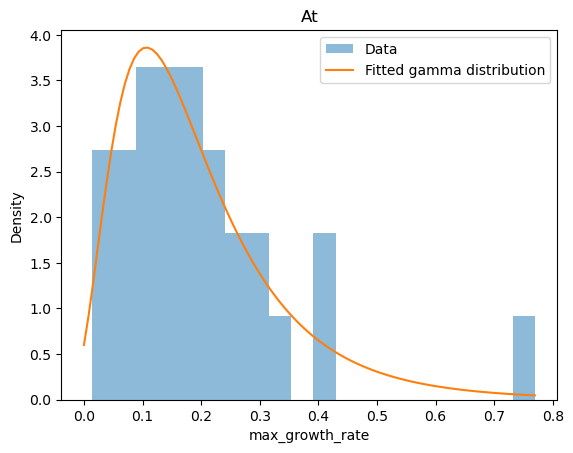

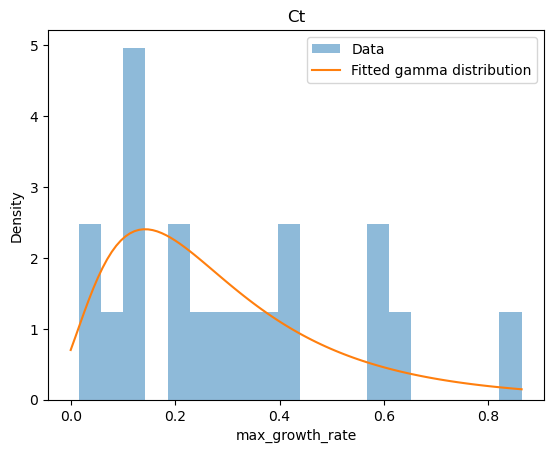

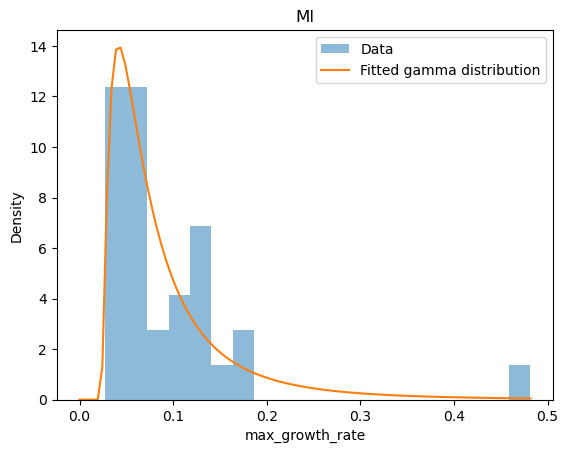

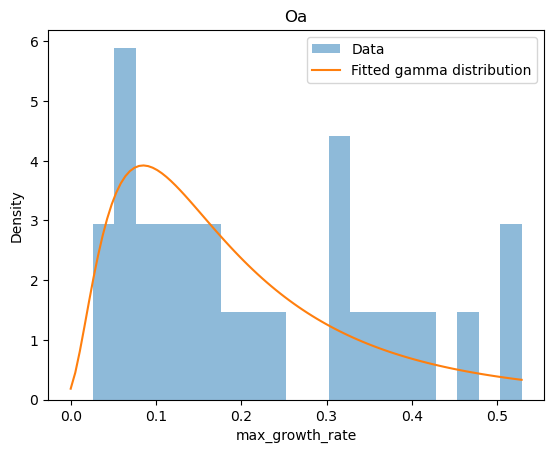

In [255]:
# Draw the distribution of effective growth rates for each species and the fitted gamma distribution
for name in species:
    dfi = rate_df[rate_df['Species'] == name]
    plt.figure()
    plt.hist(dfi.loc[dfi[growth_rate_estimate].notna(), growth_rate_estimate], bins=20, density=True, alpha=0.5, label='Data')
    x = np.linspace(0, dfi[growth_rate_estimate].max(), 100)
    y = st.lognorm.pdf(x, *c_fit[name])
    plt.plot(x, y, label='Fitted gamma distribution')
    plt.title(name)
    plt.xlabel(growth_rate_estimate)
    plt.ylabel('Density')
    plt.legend()

In [256]:
exchanges += [f'R_EX_{m_id}_e' for m_id in ['btn']]# 'R_EX_thmpp_e'

In [257]:
exchanges = sorted(exchanges)
species = ['At', 'Ct', 'Ml', 'Oa']
def make_C_w(model_data, exchanges, m):
    C = np.zeros((len(species), len(exchanges)))
    W = np.zeros((len(species), len(exchanges)))
    for i, name in enumerate(species):
        for j, r_id in enumerate(exchanges):
            if r_id in model_data[name]['growth_exchanges']:
                try:
                    mu_eff = ex_rxn_to_mu_eff[(name, r_id)]
                except KeyError:
                    mu_eff = max(0, st.lognorm.rvs(*c_fit[name]))
                
                w = model_data[name]['energy_dict'][r_id]
                cmax = (mu_eff + m)/(1-l)/w

                C[i,j] = max(cmax, 0)
                W[i,j] = model_data[name]['energy_dict'][r_id]
    return C, W

In [258]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Get auxotrophy yields

In [259]:
Ml = model_dict['Ml']

In [260]:
aux_yield_dict = {}
aux_yield_dict['R_EX_cys__L_e'] = 1/Ml.reactions['Growth'].stoichiometry['M_cys__L_c']
aux_yield_dict['R_EX_btn_e'] = 1/Ml.reactions['Growth'].stoichiometry['M_btn_c']
aux_yield_dict['R_EX_thmpp_e'] = 1/Ml.reactions['Growth'].stoichiometry['M_thmpp_c']

# Estimate metabolite value

In [261]:
cs_class_fn = data_folder / 'carveme_universe_met_info_and_class.csv'
cs_class_df = pd.read_csv(cs_class_fn, index_col=0)

ols_fn = data_folder / 'ols_summary_value_group_charge.csv'
ols_df = pd.read_csv(ols_fn, index_col=0)

In [262]:
id_to_class = cs_class_df.set_index('Metabolite ID')['Defined class'].to_dict()
id_to_charge = cs_class_df.set_index('Metabolite ID')['Charge'].to_dict()

In [263]:
def calc_release(m_id, log10_mv, cs_class_df, ols_df):
    m_id = m_id[2:-1]
    cs_class = id_to_class[m_id]
    charge = id_to_charge[m_id]
    

In [264]:
def calc_shadow_price(model, r_id, delta = 0.01):
    sol0 = reframed.FBA(model, constraints={'R_EX_glc__D_e':(-10,0), 'R_EX_ac_e':(-10,0), 'R_EX_glu__L_e':(-10,0), r_id:0}, objective='Growth', minimize=False)
    sol1 = reframed.FBA(model, constraints={'R_EX_glc__D_e':(-10,0), 'R_EX_ac_e':(-10,0), 'R_EX_glu__L_e':(-10,0), r_id:delta}, objective='Growth', minimize=False)
    sp = (sol1.fobj - sol0.fobj)/delta
    return sp

In [265]:
for name in species:
    ex_production_mets = []
    model = model_dict[name]
    m_id_to_r_id_ex =  {}
    for r_id in model_data[name]['ex_production_exchanges']:
        m_id = model.reactions[r_id].get_substrates()[0]
        ex_production_mets.append(m_id)
        m_id_to_r_id_ex[m_id] = r_id
    
    in_production_mets = []
    m_id_to_r_id_in =  {}
    for r_id in model_data[name]['in_production_exchanges']:
        m_id = model.reactions[r_id].get_substrates()[0]
        m_c_id = m_id[:-1]+'c'
        in_production_mets.append(m_c_id)
        m_id_to_r_id_in[m_c_id] = r_id

    sp_dict = shadow_prices[name]
    sp_df = pd.DataFrame(sp_dict)
    # model_data[name]['ex_production_sp'] = sp_df.loc[ex_production_mets].median()
    # model_data[name]['in_production_sp'] = sp_df.loc[in_production_mets].median()
    
    ex_sp = sp_df.loc[ex_production_mets].median(axis=1)
    in_sp = sp_df.loc[in_production_mets].median(axis=1)

    for m_id, value in ex_sp.items():
        if value >= 0:
            r_id = m_id_to_r_id_ex[m_id]
            try:
                new_value = calc_shadow_price(model, r_id)
            except:
                new_value = 0
            print('Ex: ', m_id, name, value, new_value)
            # m_c = idx[:-1]+'c'
            # c_val =  sp_df.loc[m_c].median()
            # if c_val < 0:
            ex_sp.loc[m_id] = new_value

    for m_id, value in in_sp.items():
        if value >= 0:
            # Add a temporary demand reaction for the exchange
            dm_id = f'R_DM_{m_id}'
            model.add_reaction_from_str(f'{dm_id}: {m_id} <->  [0, 1000]')
            try:
                new_value = calc_shadow_price(model, dm_id)
            except:
                new_value = 0
            
            print('In: ', m_id, name, value, new_value)
            model.remove_reactions([dm_id])
            in_sp.loc[m_id] = new_value
    
    mv_ex = np.log10(-ex_sp)
    mv_in = np.log10(-in_sp)

    
    min_val = -2.5
    # Replace -inf with min value
    mv_in.replace([-np.inf, np.inf], min_val, inplace = True)
    mv_ex.replace([-np.inf, np.inf], min_val, inplace = True)

    mv_in[mv_in < min_val] = min_val
    mv_ex[mv_ex < min_val] = min_val

    model_data[name]['log10(MV) in'] = mv_in
    model_data[name]['log10(MV) ex'] = mv_ex
    model_data[name]['ex mets'] = ex_production_mets
    model_data[name]['in mets'] = in_production_mets
    model_data[name]['m_id_to_r_id ex'] = m_id_to_r_id_ex
    model_data[name]['m_id_to_r_id in'] = m_id_to_r_id_in

    
    

Ex:  M_gly_e At 0.0 -0.02728650131493815
Ex:  M_fald_e At 0.0 -0.01920161203678994
Ex:  M_cit_e At 0.0 -0.07579583698560377
Ex:  M_btn_e At 0.0 -0.7597501892135039
Ex:  M_4hbz_e At 0.0 -0.40629275986061586
In:  M_btn_c At 0.0 -0.7597501892128822
Ex:  M_arg__L_e Ct 0.0 -0.10964377467024278
Ex:  M_ins_e Ct 0.0 -0.17610199683284478
Ex:  M_spmd_e Ct 0.0 -0.34376355361818156
Ex:  M_btn_e Ct 0.0 -0.5460882768321351
Ex:  M_rib__D_e Ct 0.0 -0.10210474083665044
Ex:  M_cellb_e Ct 0.0 -0.2261710150145868
In:  M_spmd_c Ct 0.0010171722701418431 -0.34278020137904486
In:  M_glc__D_c Ct 0.0 -0.11308550750733781
In:  M_btn_c Ct 0.0 -0.5460882768322683
In:  M_cellb_c Ct 0.0 -0.22617101501468673
Ex:  M_orot_e Ml 0.0 -1.1102230246251565e-14
Ex:  M_anhgm_e Ml 0.0 0.0


/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Ex:  M_orot_e Oa 0.0 -0.05016143041887133
Ex:  M_fald_e Oa 0.0 -0.019061343558846033
Ex:  M_etha_e Oa 0.0 -0.06420663093458234
Ex:  M_btn_e Oa 0.0 -0.746183846413917
In:  M_etha_c Oa 0.0 -0.06420663093555934
In:  M_btn_c Oa 0.0 -0.7461838464149606


In [266]:
# Use OLS model to predict function values for metabolites in mv_ex
def predict_function_value(m_id, mv_value, ols_df, id_to_class, id_to_charge):
    """
    Predict function value using the OLS linear model:
    value = Intercept + Group_coef + B*mv_in + C*charge
    """
    # Clean metabolite ID (remove M_ prefix and _e suffix)
    m_id_clean = m_id[2:-2]  # M_xxx_e -> xxx
    
    # Get metabolite properties
    met_class = id_to_class.get(m_id_clean, 'Other')  # default class
    charge = id_to_charge.get(m_id_clean, 0)  # default charge
    
    # Get coefficients from OLS model
    intercept = ols_df.loc['Intercept', 'Coef.']
    B_coef = ols_df.loc['B', 'Coef.']
    C_coef = ols_df.loc['C', 'Coef.']
    
    # Get group coefficient (default to 0 for reference category)
    group_key = f'G[T.{met_class}]'
    if group_key in ols_df.index:
        group_coef = ols_df.loc[group_key, 'Coef.']
    else:
        group_coef = 0  # Reference category
    
    # Calculate predicted value
    predicted = intercept + group_coef + B_coef * mv_value + C_coef * charge
    
    return predicted

# Apply predictions to all metabolites in mv_ex
for name in species:
    print(f"Predictions for {name}:")
    mv_ex = model_data[name]['log10(MV) ex']
    mv_in = model_data[name]['log10(MV) in']
    ex_log_release = {}
    for m_id, mv in mv_ex.items():
        predicted_value = predict_function_value(m_id, mv, ols_df, id_to_class, id_to_charge)
        print(f'Metabolite: {m_id}, log10(MV): {mv:.2f}, Predicted function value: {predicted_value:.2f}')
        r_id = model_data[name]['m_id_to_r_id ex'][m_id]
        ex_log_release[r_id] = predicted_value

    in_log_release = {}
    for m_id, mv in mv_in.items():
        predicted_value = predict_function_value(m_id, mv, ols_df, id_to_class, id_to_charge)
        print(f'Metabolite: {m_id}, log10(MV): {mv:.2f}, Predicted function value: {predicted_value:.2f}')
        r_id = model_data[name]['m_id_to_r_id in'][m_id]
        in_log_release[r_id] = predicted_value
    model_data[name]['ex_log_release'] = ex_log_release
    model_data[name]['in_log_release'] = in_log_release


Predictions for At:
Metabolite: M_orot_e, log10(MV): -1.27, Predicted function value: -3.53
Metabolite: M_etoh_e, log10(MV): -1.26, Predicted function value: -2.36
Metabolite: M_gly_e, log10(MV): -1.56, Predicted function value: -3.44
Metabolite: M_tyr__L_e, log10(MV): -0.75, Predicted function value: -4.63
Metabolite: M_arg__L_e, log10(MV): -0.97, Predicted function value: -3.76
Metabolite: M_thm_e, log10(MV): -0.47, Predicted function value: -3.59
Metabolite: M_ins_e, log10(MV): -0.77, Predicted function value: -3.71
Metabolite: M_spmd_e, log10(MV): -0.86, Predicted function value: -1.90
Metabolite: M_acon_C_e, log10(MV): -1.10, Predicted function value: -3.22
Metabolite: M_fum_e, log10(MV): -1.27, Predicted function value: -2.96
Metabolite: M_glc__D_e, log10(MV): -0.97, Predicted function value: -3.41
Metabolite: M_ser__L_e, log10(MV): -1.38, Predicted function value: -3.70
Metabolite: M_anhgm_e, log10(MV): -0.48, Predicted function value: -4.13
Metabolite: M_ac_e, log10(MV): -1.54,

# Store data

In [267]:
param_fn = data_folder / 'CRM_parameters.pkl'


In [268]:
model_data['all_in_production_exchanges'] = all_in_production_exchanges
model_data['all_ex_production_exchanges'] = all_ex_production_exchanges
model_data['all_growth_exchanges'] = all_growth_exchanges
model_data['cs_exchanges'] = cs_exchanges
model_data['aux_yield_dict'] = aux_yield_dict
model_data['ex_rxn_to_mu'] = ex_rxn_to_mu
# model_data['C'], model_data['W'] = make_C_w(model_data, exchanges, m)
model_data['c_fit'] = c_fit
with open(param_fn, 'wb') as f:
    pickle.dump(model_data, f)

In [269]:
with open(param_fn, 'rb') as f:
    model_data = pickle.load(f)

In [270]:
# max_time = 2000
# initial_abundance = 1e-2
# m = 0.0125

# # C, W = make_C_w(model_data, exchanges, m)
# C = model_data['C']
# W = model_data['W']
# dt = 0.1
# method = 'LSODA'
# initial_c_conc = 10
# new_data = []
# N0 = np.ones(4) * initial_abundance
# dilution_rate = 0.1
# g = 1

# # for i, sdata in enumerate(tqdm(selected_data)):
# n_cs = C.shape[1]


# # D = np.random.uniform(0, 1, (n_cs, n_cs))
# D = make_D(4, n_cs)


# # K =  np.random.uniform(0.1, 10, (n_cs, 4))
# K = np.random.lognormal(-3,1.5, (n_cs, 4))
# print(K.shape)
# # for j in range(1, 2):
# R0 = np.zeros(n_cs)
# R0[0] = 15
# l = 0.1
# c = CRM(4, n_cs, C = C, D=D, dilution_rate=0.1, l=l, K=K.T, atol=1e-9, rtol=1e-9, g=1, w = W, m = m)
# # sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)

# sol = c.run_transfers(72, N0.copy(), R0.copy(), dt=dt, n_transfers = 8, method=method)

# if sol.success:
#     # new_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :],  'resource_no': j, 'key': sdata['key'], 'success': sol.success, 
#                                 # 'converged': has_converged(c.N, 1e-7)})
#     print("success")
#     plt.semilogy(c.N)
# else:
#     print(f'Integration failed. Status: {sol.success}')
#     print(f'Message: {sol.message if hasattr(sol, "message") else "No message"}')

    


In [274]:
sorted(model_data['Ct']['ex_production_exchanges'])

['R_EX_4hbz_e',
 'R_EX_LalaDgluMdapDala_e',
 'R_EX_ac_e',
 'R_EX_acald_e',
 'R_EX_acon_C_e',
 'R_EX_akg_e',
 'R_EX_ala__D_e',
 'R_EX_ala__L_e',
 'R_EX_alaala_e',
 'R_EX_anhgm_e',
 'R_EX_arg__L_e',
 'R_EX_asp__L_e',
 'R_EX_btn_e',
 'R_EX_bz_e',
 'R_EX_cellb_e',
 'R_EX_cgly_e',
 'R_EX_cit_e',
 'R_EX_cys__L_e',
 'R_EX_etoh_e',
 'R_EX_fald_e',
 'R_EX_fum_e',
 'R_EX_g3pe_e',
 'R_EX_g3pg_e',
 'R_EX_gln__L_e',
 'R_EX_glu__L_e',
 'R_EX_gly_e',
 'R_EX_glyc3p_e',
 'R_EX_gthrd_e',
 'R_EX_icit_e',
 'R_EX_ins_e',
 'R_EX_lac__L_e',
 'R_EX_leu__L_e',
 'R_EX_lys__L_e',
 'R_EX_meoh_e',
 'R_EX_met__L_e',
 'R_EX_orot_e',
 'R_EX_phe__L_e',
 'R_EX_pro__L_e',
 'R_EX_pyr_e',
 'R_EX_rib__D_e',
 'R_EX_ser__L_e',
 'R_EX_spmd_e',
 'R_EX_thm_e',
 'R_EX_thr__L_e',
 'R_EX_thym_e',
 'R_EX_tyr__L_e',
 'R_EX_ura_e',
 'R_EX_val__L_e']

In [275]:
sorted(model_data['all_growth_exchanges'])

['R_EX_14glucan_e',
 'R_EX_23camp_e',
 'R_EX_23ccmp_e',
 'R_EX_23cump_e',
 'R_EX_25dkglcn_e',
 'R_EX_26dap__M_e',
 'R_EX_2ameph_e',
 'R_EX_2ddglcn_e',
 'R_EX_2pglyc_e',
 'R_EX_34dhbz_e',
 'R_EX_34dhcinm_e',
 'R_EX_3amp_e',
 'R_EX_3cmp_e',
 'R_EX_3hcinnm_e',
 'R_EX_3hpppn_e',
 'R_EX_3mb_e',
 'R_EX_3oxoadp_e',
 'R_EX_3ump_e',
 'R_EX_4abut_e',
 'R_EX_4hbz_e',
 'R_EX_4hoxpac_e',
 'R_EX_4hphac_e',
 'R_EX_4hpro_LT_e',
 'R_EX_4hptn_e',
 'R_EX_4oxptn_e',
 'R_EX_5aptn_e',
 'R_EX_5dglcn_e',
 'R_EX_6atha_e',
 'R_EX_6hnac_e',
 'R_EX_LalaDgluMdapDala_e',
 'R_EX_LalaLglu_e',
 'R_EX_R_3hcmrs7e_e',
 'R_EX_R_3hphpa_e',
 'R_EX_R_3hphxa_e',
 'R_EX_R_3hpocta_e',
 'R_EX_R_3hppta_e',
 'R_EX_ac_e',
 'R_EX_acac_e',
 'R_EX_acald_e',
 'R_EX_acgam_e',
 'R_EX_acmana_e',
 'R_EX_acnam_e',
 'R_EX_acon_C_e',
 'R_EX_actn__R_e',
 'R_EX_ad_e',
 'R_EX_ade_e',
 'R_EX_adn_e',
 'R_EX_agm_e',
 'R_EX_akg_e',
 'R_EX_ala_B_e',
 'R_EX_ala_L_asp__L_e',
 'R_EX_ala_L_glu__L_e',
 'R_EX_ala_L_thr__L_e',
 'R_EX_ala__D_e',
 'R_EX_ala__